# ThinkDSP — Глава 3. Апериодические сигналы



In [1]:
import os

if not os.path.exists('thinkdsp.py'):
    !wget https://github.com/AllenDowney/ThinkDSP/raw/master/code/thinkdsp.py

--2026-05-12 10:37:14--  https://github.com/AllenDowney/ThinkDSP/raw/master/code/thinkdsp.py
Resolving github.com (github.com)... 140.82.113.4
Connecting to github.com (github.com)|140.82.113.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/AllenDowney/ThinkDSP/master/code/thinkdsp.py [following]
--2026-05-12 10:37:14--  https://raw.githubusercontent.com/AllenDowney/ThinkDSP/master/code/thinkdsp.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 48554 (47K) [text/plain]
Saving to: ‘thinkdsp.py’

thinkdsp.py         100%[===================>]  47.42K  --.-KB/s    in 0.003s  

2026-05-12 10:37:14 (17.1 MB/s) - ‘thinkdsp.py’ saved [48554/48554]



In [2]:
import numpy as np
import matplotlib.pyplot as plt

from thinkdsp import decorate, SinSignal, Chirp, normalize, unbias, read_wave

PI2 = 2 * np.pi

## Упражнение 3.1

В примере с утечкой спектра заменим окно Хэмминга другими окнами NumPy и сравним, как они уменьшают утечку.


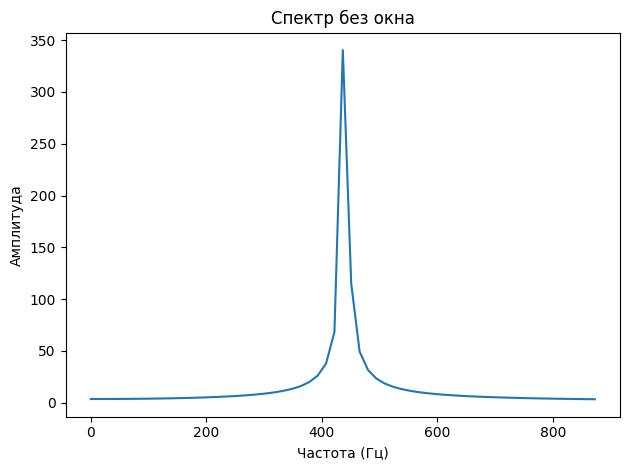

In [3]:
signal = SinSignal(freq=440)
duration = signal.period * 30.25   # нецелое число периодов -> появляется утечка
wave = signal.make_wave(duration)
spectrum = wave.make_spectrum()

spectrum.plot(high=880)
decorate(xlabel='Частота (Гц)', ylabel='Амплитуда', title='Спектр без окна')

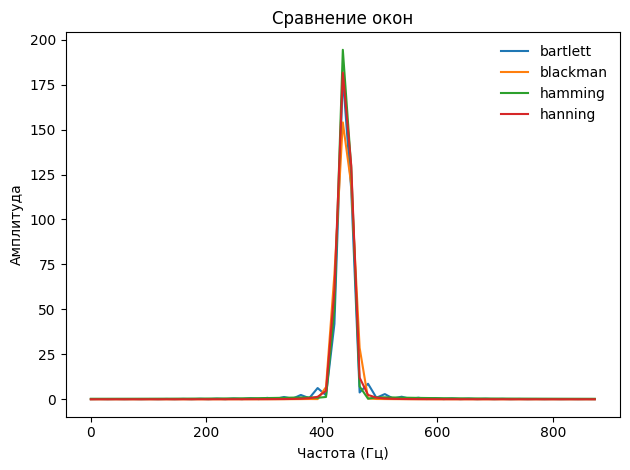

In [4]:
for window_func in [np.bartlett, np.blackman, np.hamming, np.hanning]:
    wave = signal.make_wave(duration)
    wave.ys *= window_func(len(wave.ys))

    spectrum = wave.make_spectrum()
    spectrum.plot(high=880, label=window_func.__name__)

decorate(xlabel='Частота (Гц)', ylabel='Амплитуда', title='Сравнение окон')

**Вывод.** Все четыре окна заметно уменьшают утечку спектра. Окно Bartlett оставляет больше побочных колебаний. Окно Hamming хорошо подавляет утечку и при этом меньше рассеивает энергию основного пика.


## Упражнение 3.2

Напишем класс `SawtoothChirp`, который наследуется от `Chirp`, но вместо синусоиды генерирует пилообразный сигнал с линейно меняющейся частотой.


In [5]:
class SawtoothChirp(Chirp):
    """Пилообразный chirp-сигнал с изменяющейся частотой."""

    def evaluate(self, ts):
        """Вычисляет значения сигнала в моменты времени ts."""
        freqs = np.linspace(self.start, self.end, len(ts))
        dts = np.diff(ts, prepend=0)
        dphis = PI2 * freqs * dts
        phases = np.cumsum(dphis)

        cycles = phases / PI2
        frac, _ = np.modf(cycles)          # фаза в долях цикла от 0 до 1
        ys = normalize(unbias(frac), self.amp)
        return ys

In [6]:
signal = SawtoothChirp(start=220, end=880)
wave = signal.make_wave(duration=1, framerate=4000)
wave.apodize()
wave.make_audio()

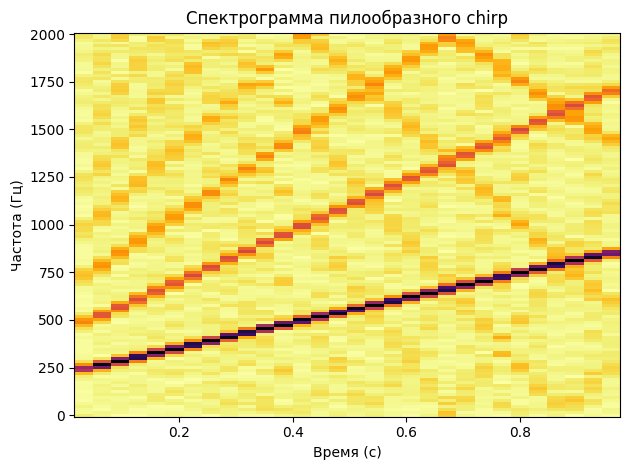

In [7]:
sp = wave.make_spectrogram(256)
sp.plot()
decorate(xlabel='Время (с)', ylabel='Частота (Гц)', title='Спектрограмма пилообразного chirp')

На низкой частоте дискретизации видны гармоники, которые отражаются от частоты свёртки. Именно они дают слышимый «шипящий» фон. При увеличении `framerate` алиасинг становится меньше.


In [8]:
# Дополнительно: пример похожего звука из Star Trek, если файл отсутствует — загрузим.
if not os.path.exists('tos-redalert.wav'):
    !wget https://github.com/AllenDowney/ThinkDSP/raw/master/code/tos-redalert.wav

read_wave('tos-redalert.wav').make_audio()

--2026-05-12 10:38:30--  https://github.com/AllenDowney/ThinkDSP/raw/master/code/tos-redalert.wav
Resolving github.com (github.com)... 140.82.113.3
Connecting to github.com (github.com)|140.82.113.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/AllenDowney/ThinkDSP/master/code/tos-redalert.wav [following]
--2026-05-12 10:38:30--  https://raw.githubusercontent.com/AllenDowney/ThinkDSP/master/code/tos-redalert.wav
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.111.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 13444 (13K) [audio/wav]
Saving to: ‘tos-redalert.wav’

tos-redalert.wav    100%[===================>]  13.13K  --.-KB/s    in 0s      

2026-05-12 10:38:30 (102 MB/s) - ‘tos-redalert.wav’ saved [13444/13444]



/content/thinkdsp.py:1112: RuntimeWarning: overflow encountered in scalar absolute
  high, low = abs(max(ys)), abs(min(ys))


## Упражнение 3.3

Создадим пилообразный chirp от 2500 до 3000 Гц длительностью 1 с с частотой кадров 20 кГц и посмотрим на его спектр.

Ожидание: основная частота даст широкую область в диапазоне 2500–3000 Гц. Первая гармоника попадёт в 5000–6000 Гц, вторая — в 7500–9000 Гц. Более высокие гармоники частично отразятся из-за алиасинга.


In [9]:
signal = SawtoothChirp(start=2500, end=3000)
wave = signal.make_wave(duration=1, framerate=20000)
wave.make_audio()

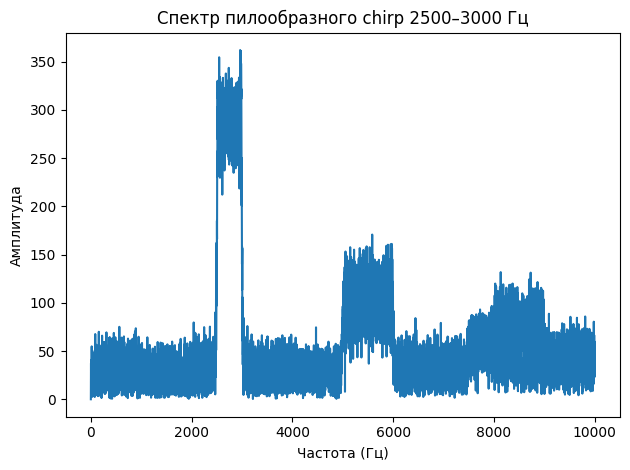

In [10]:
wave.make_spectrum().plot()
decorate(xlabel='Частота (Гц)', ylabel='Амплитуда', title='Спектр пилообразного chirp 2500–3000 Гц')

**Вывод.** Спектр действительно содержит энергию в ожидаемых диапазонах фундаментальной частоты и гармоник. Из-за пилообразной формы сигнал богат гармониками, поэтому энергия распределяется шире, чем у синусоидального chirp.


## Упражнение 3.4

Глиссандо — это переход от одной высоты звука к другой, то есть музыкальный аналог chirp. Загрузим пример глиссандо и построим спектрограмму.


In [11]:
if not os.path.exists('72475__rockwehrmann__glissup02.wav'):
    !wget https://github.com/AllenDowney/ThinkDSP/raw/master/code/72475__rockwehrmann__glissup02.wav

wave = read_wave('72475__rockwehrmann__glissup02.wav')
wave.make_audio()

--2026-05-12 10:39:17--  https://github.com/AllenDowney/ThinkDSP/raw/master/code/72475__rockwehrmann__glissup02.wav
Resolving github.com (github.com)... 140.82.113.4
Connecting to github.com (github.com)|140.82.113.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/AllenDowney/ThinkDSP/master/code/72475__rockwehrmann__glissup02.wav [following]
--2026-05-12 10:39:18--  https://raw.githubusercontent.com/AllenDowney/ThinkDSP/master/code/72475__rockwehrmann__glissup02.wav
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1081388 (1.0M) [audio/wav]
Saving to: ‘72475__rockwehrmann__glissup02.wav’

72475__rockwehrmann 100%[===================>]   1.03M  --.-KB/s    in 0.009s  

2026-05-12 10:39:18 (111 M

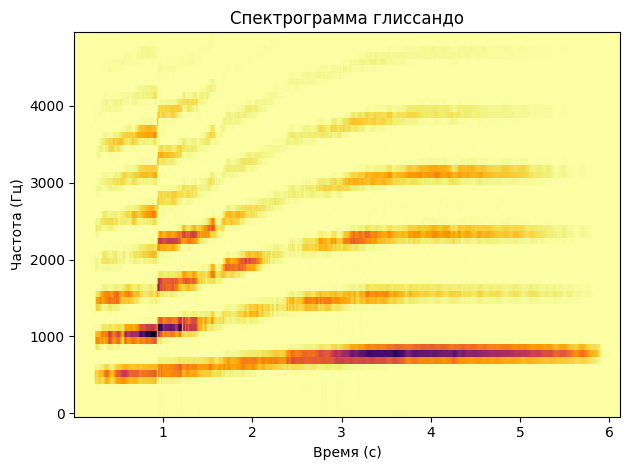

In [12]:
wave.make_spectrogram(512).plot(high=5000)
decorate(xlabel='Время (с)', ylabel='Частота (Гц)', title='Спектрограмма глиссандо')

На спектрограмме видно движение основной частоты и гармоник вверх: это типичная картина глиссандо.


## Упражнение 3.5

Для тромбона высота звука обратно пропорциональна длине трубы. Если кулиса движется с постоянной скоростью, длина меняется линейно, а частота меняется как обратная величина длины.

Поэтому такой glissando не является строго линейным chirp; он ближе к нелинейному изменению частоты, но на небольшом диапазоне может визуально напоминать линейный.


In [13]:
class TromboneGliss(Chirp):
    """Сигнал, моделирующий тромбоновое глиссандо."""

    def evaluate(self, ts):
        """Вычисляет сигнал при частоте, обратно пропорциональной длине трубы."""
        l1, l2 = 1.0 / self.start, 1.0 / self.end
        lengths = np.linspace(l1, l2, len(ts))
        freqs = 1 / lengths

        dts = np.diff(ts, prepend=0)
        dphis = PI2 * freqs * dts
        phases = np.cumsum(dphis)
        ys = self.amp * np.cos(phases)
        return ys

In [14]:
low = 262   # C3
high = 349  # F3

signal = TromboneGliss(high, low)
wave1 = signal.make_wave(duration=1)
wave1.apodize()
wave1.make_audio()

In [15]:
signal = TromboneGliss(low, high)
wave2 = signal.make_wave(duration=1)
wave2.apodize()
wave2.make_audio()

In [16]:
wave = wave1 | wave2
wave.make_audio()

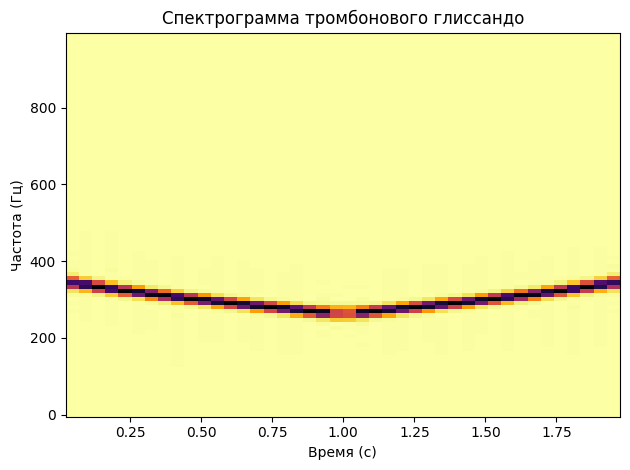

In [17]:
sp = wave.make_spectrogram(1024)
sp.plot(high=1000)
decorate(xlabel='Время (с)', ylabel='Частота (Гц)', title='Спектрограмма тромбонового глиссандо')

**Вывод.** Частота меняется обратно пропорционально линейно меняющейся длине трубы. Поэтому физически это не линейный chirp. На спектрограмме кривая слегка нелинейна; в малом диапазоне она может выглядеть почти прямой.


## Упражнение 3.6

Возьмём запись последовательности гласных и рассмотрим спектрограмму. Разные гласные отличаются прежде всего формантами — устойчивыми пиками в спектре речевого сигнала.


In [18]:
if not os.path.exists('87778__marcgascon7__vocals.wav'):
    !wget https://github.com/AllenDowney/ThinkDSP/raw/master/code/87778__marcgascon7__vocals.wav

wave = read_wave('87778__marcgascon7__vocals.wav')
wave.make_audio()


--2026-05-12 10:41:05--  https://github.com/AllenDowney/ThinkDSP/raw/master/code/87778__marcgascon7__vocals.wav
Resolving github.com (github.com)... 140.82.112.3
Connecting to github.com (github.com)|140.82.112.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/AllenDowney/ThinkDSP/master/code/87778__marcgascon7__vocals.wav [following]
--2026-05-12 10:41:05--  https://raw.githubusercontent.com/AllenDowney/ThinkDSP/master/code/87778__marcgascon7__vocals.wav
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1399852 (1.3M) [audio/wav]
Saving to: ‘87778__marcgascon7__vocals.wav’

87778__marcgascon7_ 100%[===================>]   1.33M  --.-KB/s    in 0.009s  

2026-05-12 10:41:05 (144 MB/s) - ‘87778__m

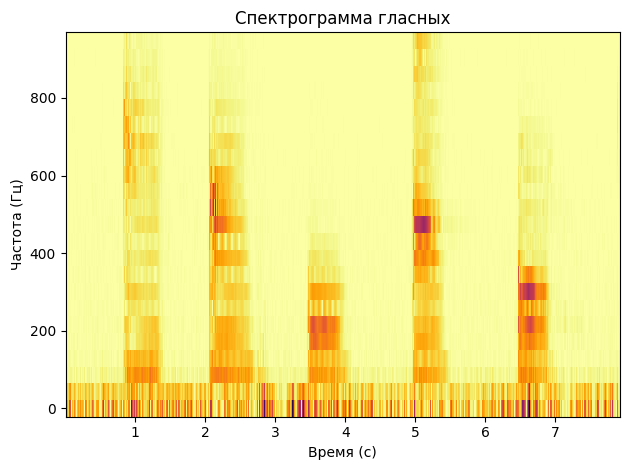

In [19]:
wave.make_spectrogram(1024).plot(high=1000)
decorate(xlabel='Время (с)', ylabel='Частота (Гц)', title='Спектрограмма гласных')


Нижняя горизонтальная полоса, скорее всего, является фоновым шумом. Более информативны форманты — области повышенной энергии на частотах выше основного тона.


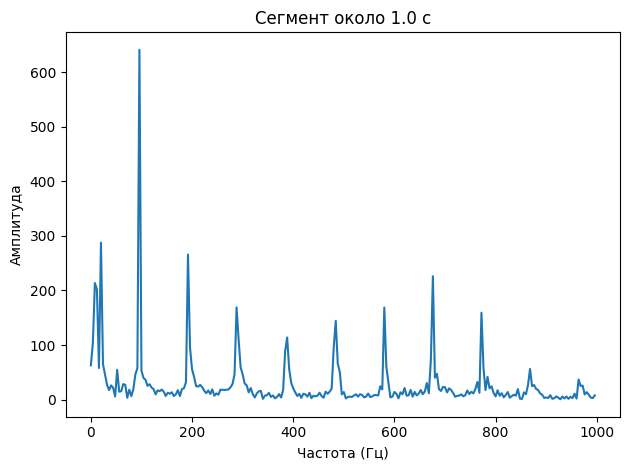

In [20]:
high = 1000

segment = wave.segment(start=1, duration=0.25)
segment.make_spectrum().plot(high=high)
decorate(xlabel='Частота (Гц)', ylabel='Амплитуда', title='Сегмент около 1.0 с')

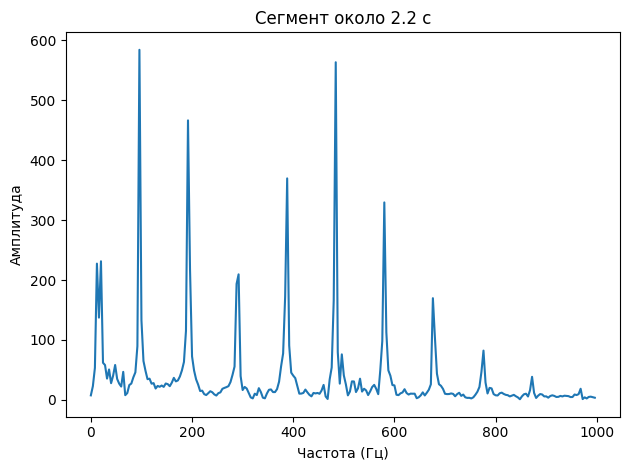

In [21]:
segment = wave.segment(start=2.2, duration=0.25)
segment.make_spectrum().plot(high=high)
decorate(xlabel='Частота (Гц)', ylabel='Амплитуда', title='Сегмент около 2.2 с')

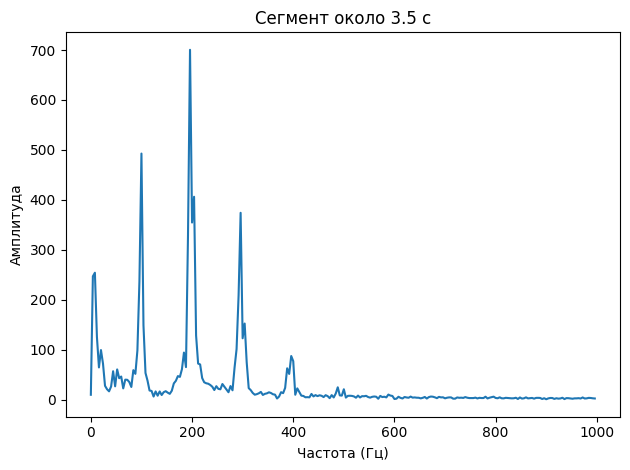

In [22]:
segment = wave.segment(start=3.5, duration=0.25)
segment.make_spectrum().plot(high=high)
decorate(xlabel='Частота (Гц)', ylabel='Амплитуда', title='Сегмент около 3.5 с')

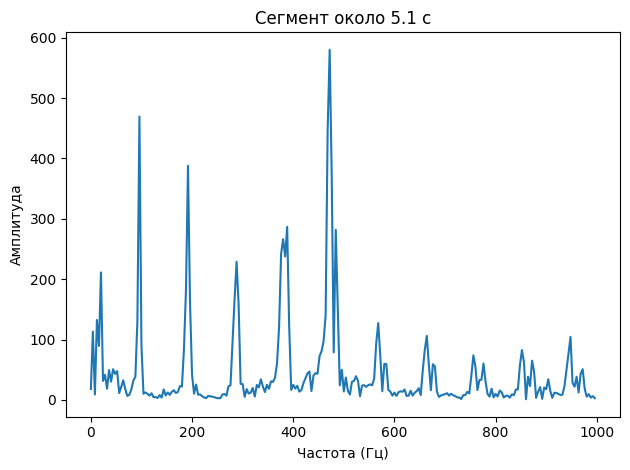

In [23]:
segment = wave.segment(start=5.1, duration=0.25)
segment.make_spectrum().plot(high=high)
decorate(xlabel='Частота (Гц)', ylabel='Амплитуда', title='Сегмент около 5.1 с')

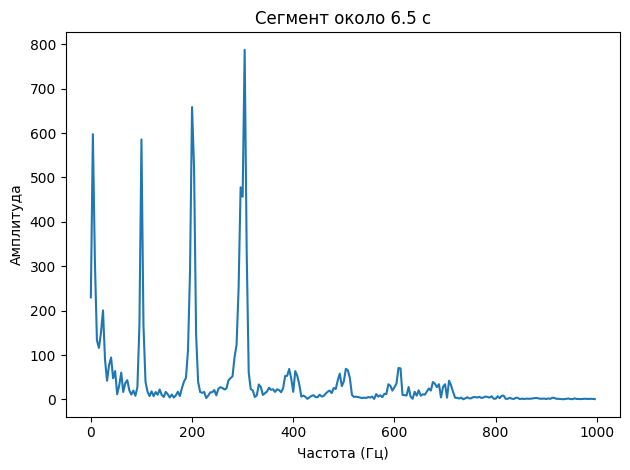

In [24]:
segment = wave.segment(start=6.5, duration=0.25)
segment.make_spectrum().plot(high=high)
decorate(xlabel='Частота (Гц)', ylabel='Амплитуда', title='Сегмент около 6.5 с')

**Вывод.** Разные гласные можно различать по расположению и относительным амплитудам формант. По одной спектрограмме точное распознавание требует опыта, но отличия между сегментами видны: у одних гласных больше энергии около 300–500 Гц, у других появляются более высокие компоненты.
